In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import librosa
import os

In [ ]:
import torchaudio

In [ ]:
import warnings
warnings.filterwarnings("ignore")

### МОДУЛЬ А

Чтобы получить характеристики микрофонов, которые калибровались, определим, для начала, какие-это были микрофоны.

In [ ]:
exp_num = list(range(53, 71)) #итзвестные номера экспериментов, в которых производилась калибровка
# известные названия микрофоном, для которых производилась калибровка
mic_names = [
    'MD_3_56_L16', 'MC_2_U87_R70', 'MC_4_A414_Niz',
    'ML_2_Ok52_R31', 'MP_2_NTG5_R91', 'MCv_1_87_L23'
]

Загрузим имеющиеся данные в табличку

In [ ]:
sp = []
main_dir = os.getcwd()
for exp in exp_num:
    for name in mic_names:
        path = os.path.abspath(os.path.join(main_dir, 'Audio_Files\\' + '{0}_{1}.wav'.format(name, exp)))
        sound, sr = librosa.load(path, sr = 22050)
        sp.append([exp, name, max(abs(sound))])

In [ ]:
df = pd.DataFrame(sp)
df.columns = ['exp_num', 'mic_name', 'max_abs_a']
df

,exp_num,mic_name,max_abs_a
0,53,MD_3_56_L16,0.531408
1,53,MC_2_U87_R70,0.005978
2,53,MC_4_A414_Niz,0.017075
3,53,ML_2_Ok52_R31,0.005416
4,53,MP_2_NTG5_R91,0.012125
...,...,...,...
103,70,MC_2_U87_R70,0.006790
104,70,MC_4_A414_Niz,0.013204
105,70,ML_2_Ok52_R31,0.008283
106,70,MP_2_NTG5_R91,0.013224


Для определения микрофона, который калибровался в эксперименте исходим их того предположения, что у этого микрофона будет максимальное значение амплитуды сигнала.

In [ ]:
print('Расстояние на 1 см:')
srt = 'В эксперименте № {} калибровлася микровон {}' # шаблон вывода
for i in [53, 56, 59, 62, 65, 68]:
    # вспомогательный датафрейм с данными только для эксперимента i
    tmp_df = df[df['exp_num'] == i]
    # индекс значения с макс амплитудой
    mic_index = list(tmp_df['max_abs_a']).index(max(tmp_df['max_abs_a'])) # номер микро с макс амплитудой
    print(srt.format(i, list(tmp_df['mic_name'])[mic_index]))

Расстояние на 1 см:
В эксперименте № 53 калибровлася микровон MD_3_56_L16
В эксперименте № 56 калибровлася микровон MC_2_U87_R70
В эксперименте № 59 калибровлася микровон MC_4_A414_Niz
В эксперименте № 62 калибровлася микровон ML_2_Ok52_R31
В эксперименте № 65 калибровлася микровон MP_2_NTG5_R91
В эксперименте № 68 калибровлася микровон MCv_1_87_L23


In [ ]:
print('Расстояние на 50 см:')
srt = 'В эксперименте № {} калибровлася микровон {}' # шаблон вывода
for i in [54, 57, 60, 63, 66, 69]:
    # индекс значения с макс амплитудой
    tmp_df = df[df['exp_num'] == i]
    mic_index = list(tmp_df['max_abs_a']).index(max(tmp_df['max_abs_a'])) # номер микро с макс амплитудой
    print(srt.format(i, list(tmp_df['mic_name'])[mic_index]))

Расстояние на 50 см:
В эксперименте № 54 калибровлася микровон MD_3_56_L16
В эксперименте № 57 калибровлася микровон MP_2_NTG5_R91
В эксперименте № 60 калибровлася микровон MC_4_A414_Niz
В эксперименте № 63 калибровлася микровон ML_2_Ok52_R31
В эксперименте № 66 калибровлася микровон MP_2_NTG5_R91
В эксперименте № 69 калибровлася микровон MD_3_56_L16


In [ ]:
print('Расстояние на 100 см:')
srt = 'В эксперименте № {} калибровлася микровон {}' # шаблон вывода
for i in [55, 58, 61, 64, 67, 70]:
    # индекс значения с макс амплитудой
    tmp_df = df[df['exp_num'] == i]
    mic_index = list(tmp_df['max_abs_a']).index(max(tmp_df['max_abs_a'])) # номер микро с макс амплитудой
    print(srt.format(i, list(tmp_df['mic_name'])[mic_index]))

Расстояние на 100 см:
В эксперименте № 55 калибровлася микровон MD_3_56_L16
В эксперименте № 58 калибровлася микровон MP_2_NTG5_R91
В эксперименте № 61 калибровлася микровон MD_3_56_L16
В эксперименте № 64 калибровлася микровон MD_3_56_L16
В эксперименте № 67 калибровлася микровон MP_2_NTG5_R91
В эксперименте № 70 калибровлася микровон MD_3_56_L16


### Выжные выводы:
При проверки предположения о том, что калибровочный микрофон будет иметь макс. значение амплитуды, выяснилась следующая проблема.
При работой с данными калибровки на расстоянии 1 см полученные данные полностью совпадают с таблицей 1 конкурсного задания.
При работе с данными калибровки на расстояние 50 см наблюдается расхождение с таблицей в экспериментах 57 и 69.
При работе с данными калибровки на расстоянии 100 см с таблице из задания совпал только микрофон MD_3_56_L16 и MP_2_NTG5_R91 из 55 и 67 экспериментов соответственно.

Имеем, что некоторые микрофоны в рассмотренных экспериментах имеют максимальное значение амплитуды более чем в трех экспериментах, что противоречит сделанному предположению о связи максимальногно значении амплитуды и расстояния до калибровочного микрофона. Следовательно, нельзя использовать данное предположение для определения того, какой микрофон в каком эксперименте калибровался.
Однако, при малых значениях расстояния (на 1 см), полученные данные полностью соответствуют таблице, представленной в задании, поэтому можно сделать предположение, что таблица в задании содержит корректные данные о том, какой микрофон в каком эксперименте был откалиброван.
Предположительно, при увеличении расстояния, в связи с разными техниченскими свойствами микрофонов, сигнал записывался слабее, чем он был по факту. Поэтому на больших расстояниях (измерение на 100 см) использовать только значение амплитуды для определния того, какой микрофон был откалиброван, нельзя.

In [ ]:
# список к именами файлов из калибровочных экспериментиов
kalib_lst = [
    'MD_3_56_L16_53.wav', 'MC_2_U87_R70_56.wav', 'MC_4_A414_Niz_59.wav', 'ML_2_Ok52_R31_62.wav', 'MP_2_NTG5_R91_65.wav', 'MCv_1_87_L23_68.wav',
    'MD_3_56_L16_54.wav', 'MC_2_U87_R70_57.wav','MC_4_A414_Niz_60.wav', 'ML_2_Ok52_R31_63.wav', 'MP_2_NTG5_R91_66.wav', 'MCv_1_87_L23_69.wav',
    'MD_3_56_L16_55.wav', 'MC_2_U87_R70_58.wav', 'MC_4_A414_Niz_61.wav', 'ML_2_Ok52_R31_64.wav', 'MP_2_NTG5_R91_67.wav', 'MCv_1_87_L23_70.wav'
]

In [ ]:
# получаем абс пути до файлов и зсчитываем из с помощью метода load библиотеки vibrosa
loaded_kalib = []
main_dir = os.getcwd() # путь до рабочей директории
for file in kalib_lst:
    path = os.path.abspath(os.path.join(main_dir, 'Audio_Files\\' + file))
    loaded_kalib.append(librosa.load(path, sr = 22050))

# Визуализация сигналов калибровочного набора (Амплитуда - время)

Для группы микрофонов с растояния 1 см

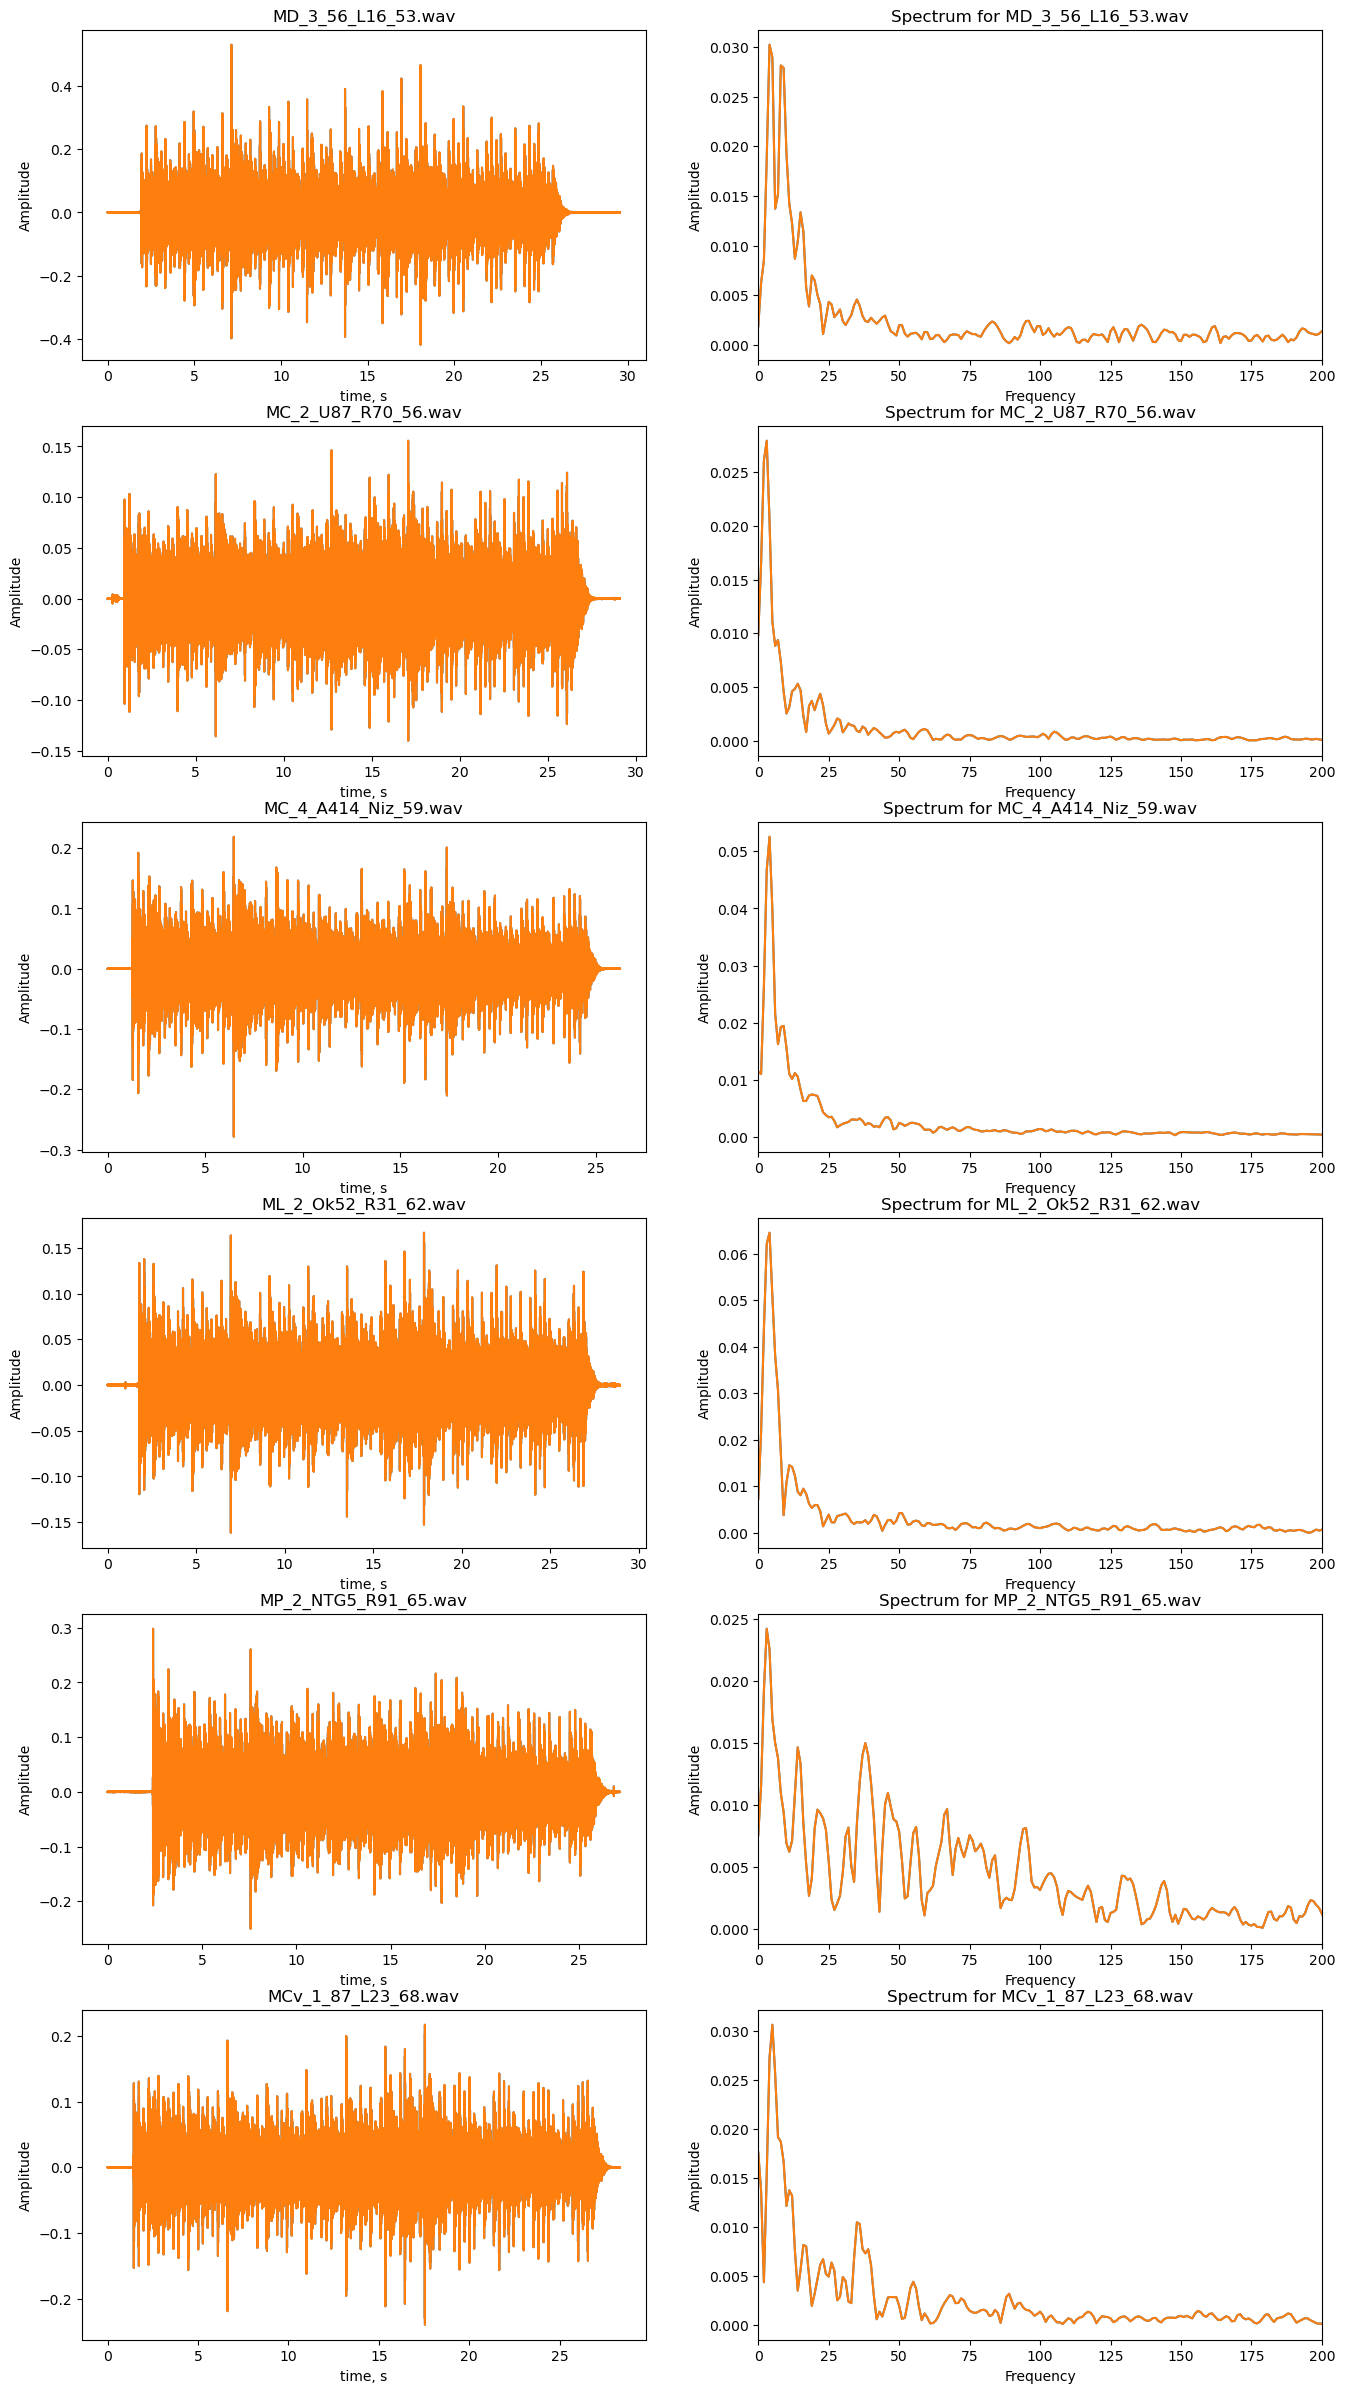

In [ ]:
fig, ax = plt.subplots(6, 2, figsize=(16, 30))
n_fft = 2048 # длина оконного сигнала после заполнения нулями (для преобразования Фурье)
for i in range(0, 6):
    for j in range(2):
        time = np.arange(0, len(loaded_kalib[i][0])) / loaded_kalib[i][1]
        ax[i][0].plot(time, loaded_kalib[i][0])
        ax[i][0].set_title(kalib_lst[i])
        ax[i][0].set_xlabel('time, s')
        ax[i][0].set_ylabel('Amplitude')
        ax[i][1].plot(np.abs(librosa.stft(loaded_kalib[i][0][:n_fft], hop_length = n_fft+1)))
        ax[i][1].set_xlim(0, 200)
        ax[i][1].set_title('Spectrum for ' + kalib_lst[i])
        ax[i][1].set_xlabel('Frequency')
        ax[i][1].set_ylabel('Amplitude')

Для группы микрофонов с растояния 50 см

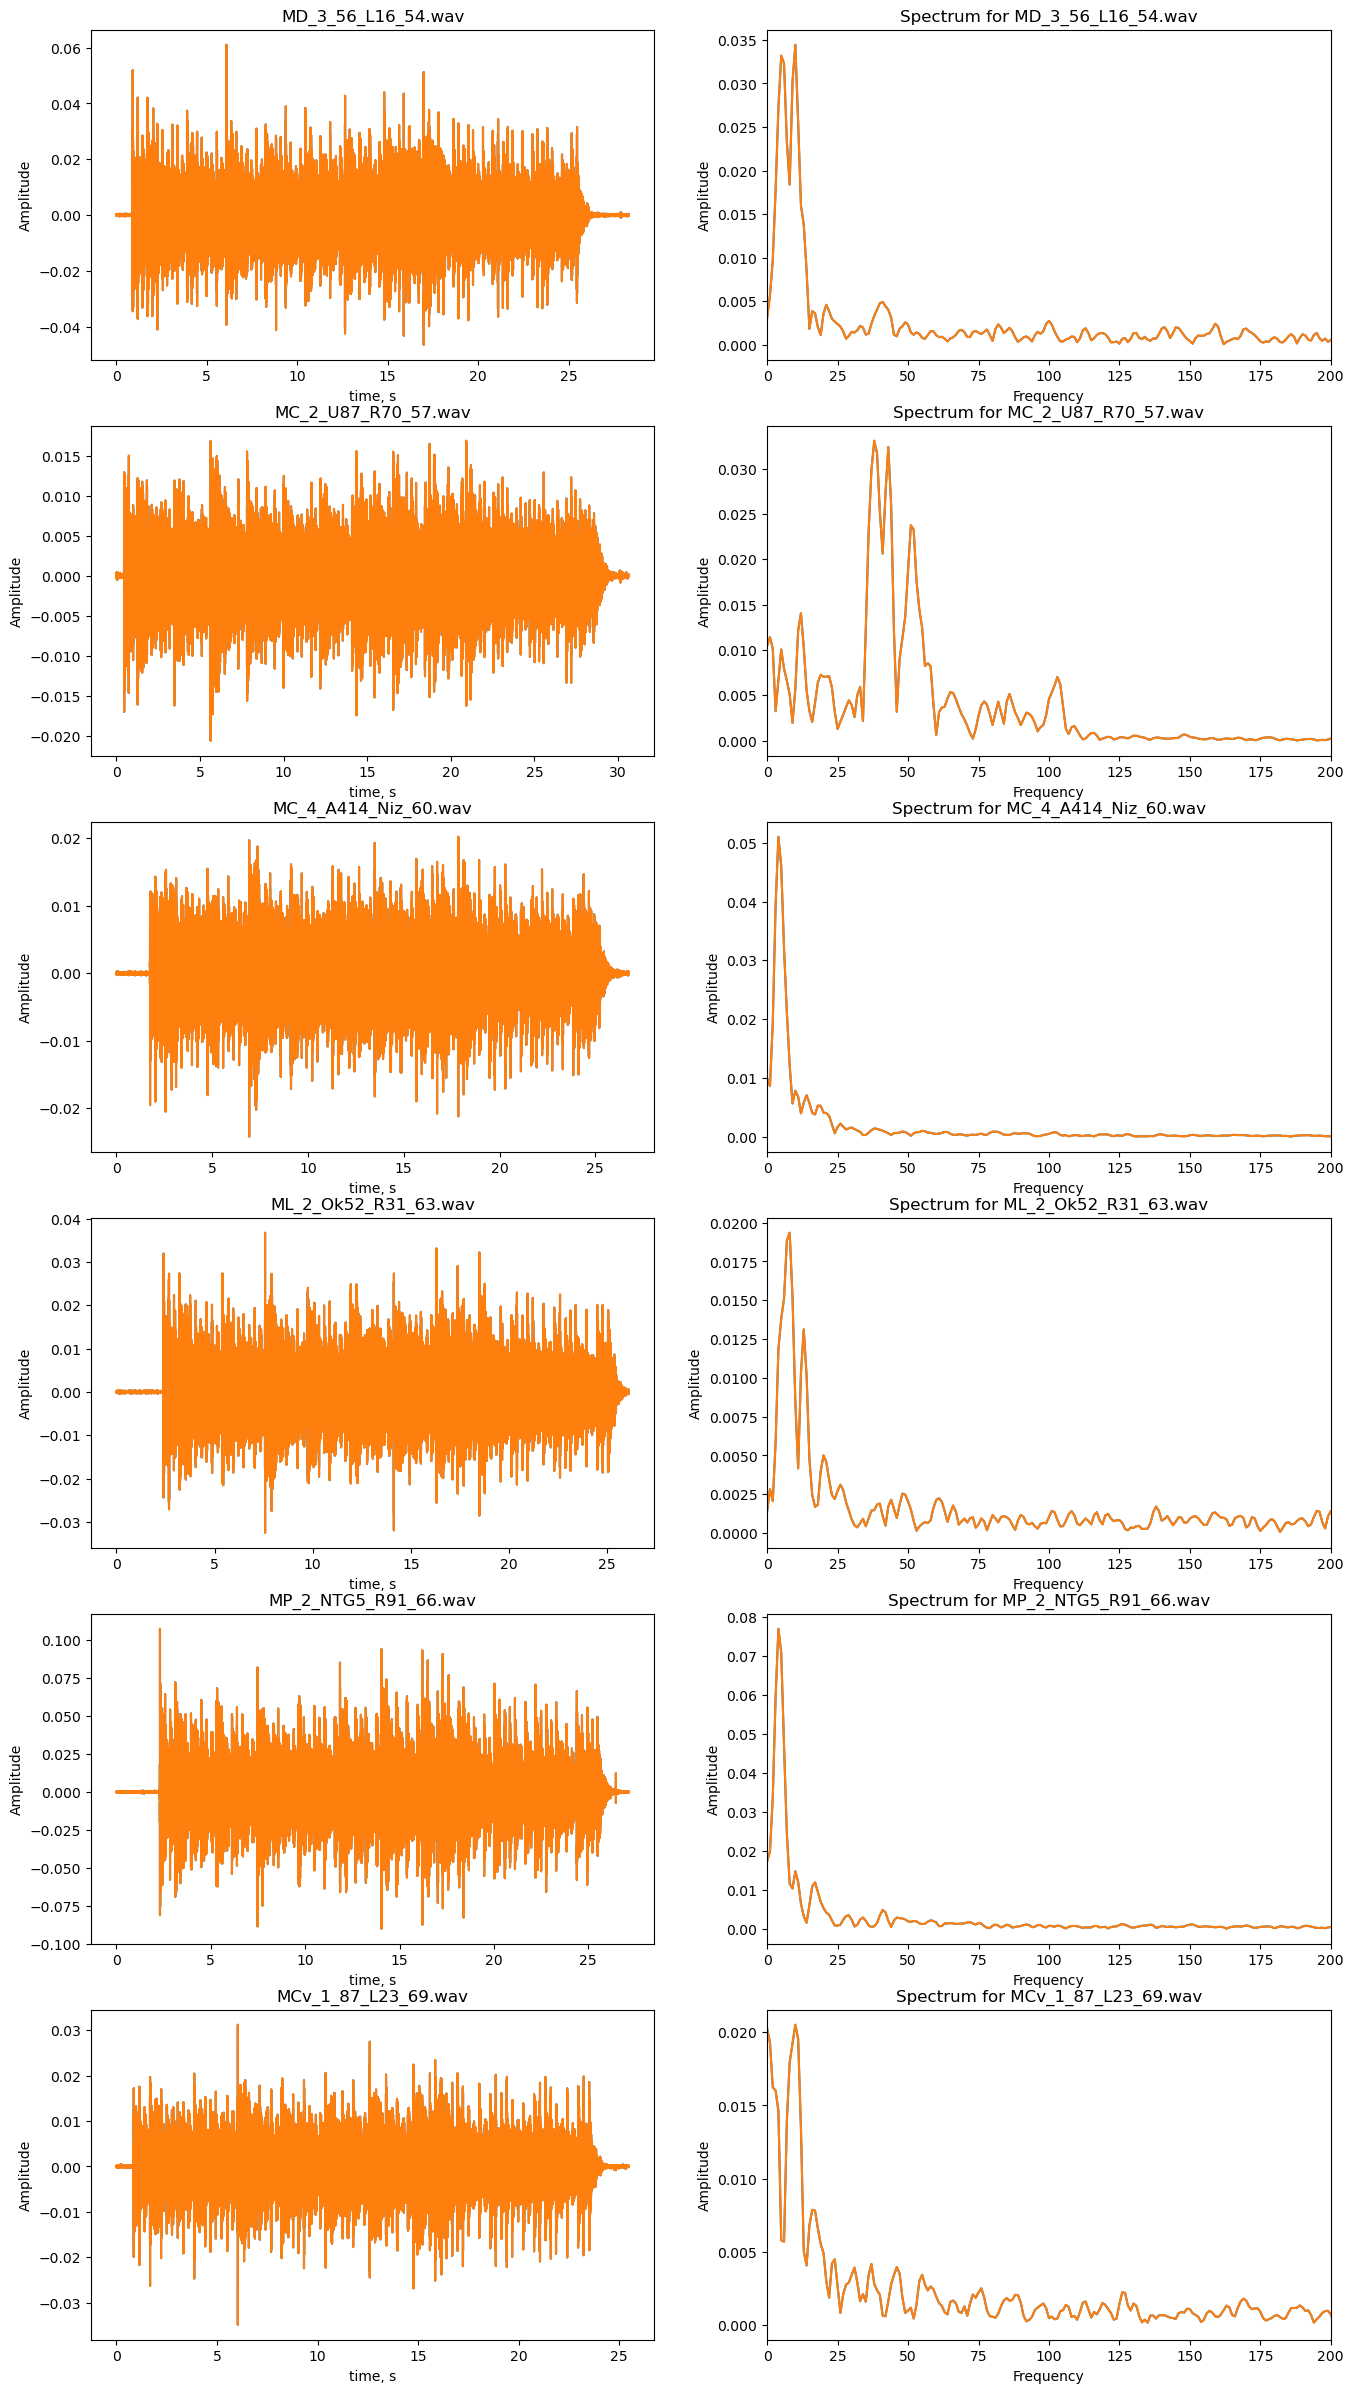

In [ ]:
fig, ax = plt.subplots(6, 2, figsize=(16, 30))
n_fft = 2048 # длина оконного сигнала после заполнения нулями (для преобразования Фурье)
for i in range(0, 6):
    for j in range(2):
        k = 6 # для переключения на вторую группу из 6 микрофонов
        time = np.arange(0, len(loaded_kalib[k+i][0])) / loaded_kalib[k+i][1]
        ax[i][0].plot(time, loaded_kalib[k+i][0])
        ax[i][0].set_title(kalib_lst[k+i])
        ax[i][0].set_xlabel('time, s')
        ax[i][0].set_ylabel('Amplitude')
        ax[i][1].plot(np.abs(librosa.stft(loaded_kalib[k+i][0][:n_fft], hop_length = n_fft+1)))
        ax[i][1].set_xlim(0, 200)
        ax[i][1].set_title('Spectrum for ' + kalib_lst[k+i])
        ax[i][1].set_xlabel('Frequency')
        ax[i][1].set_ylabel('Amplitude')

Для группы микрофонов с растояния 100 см

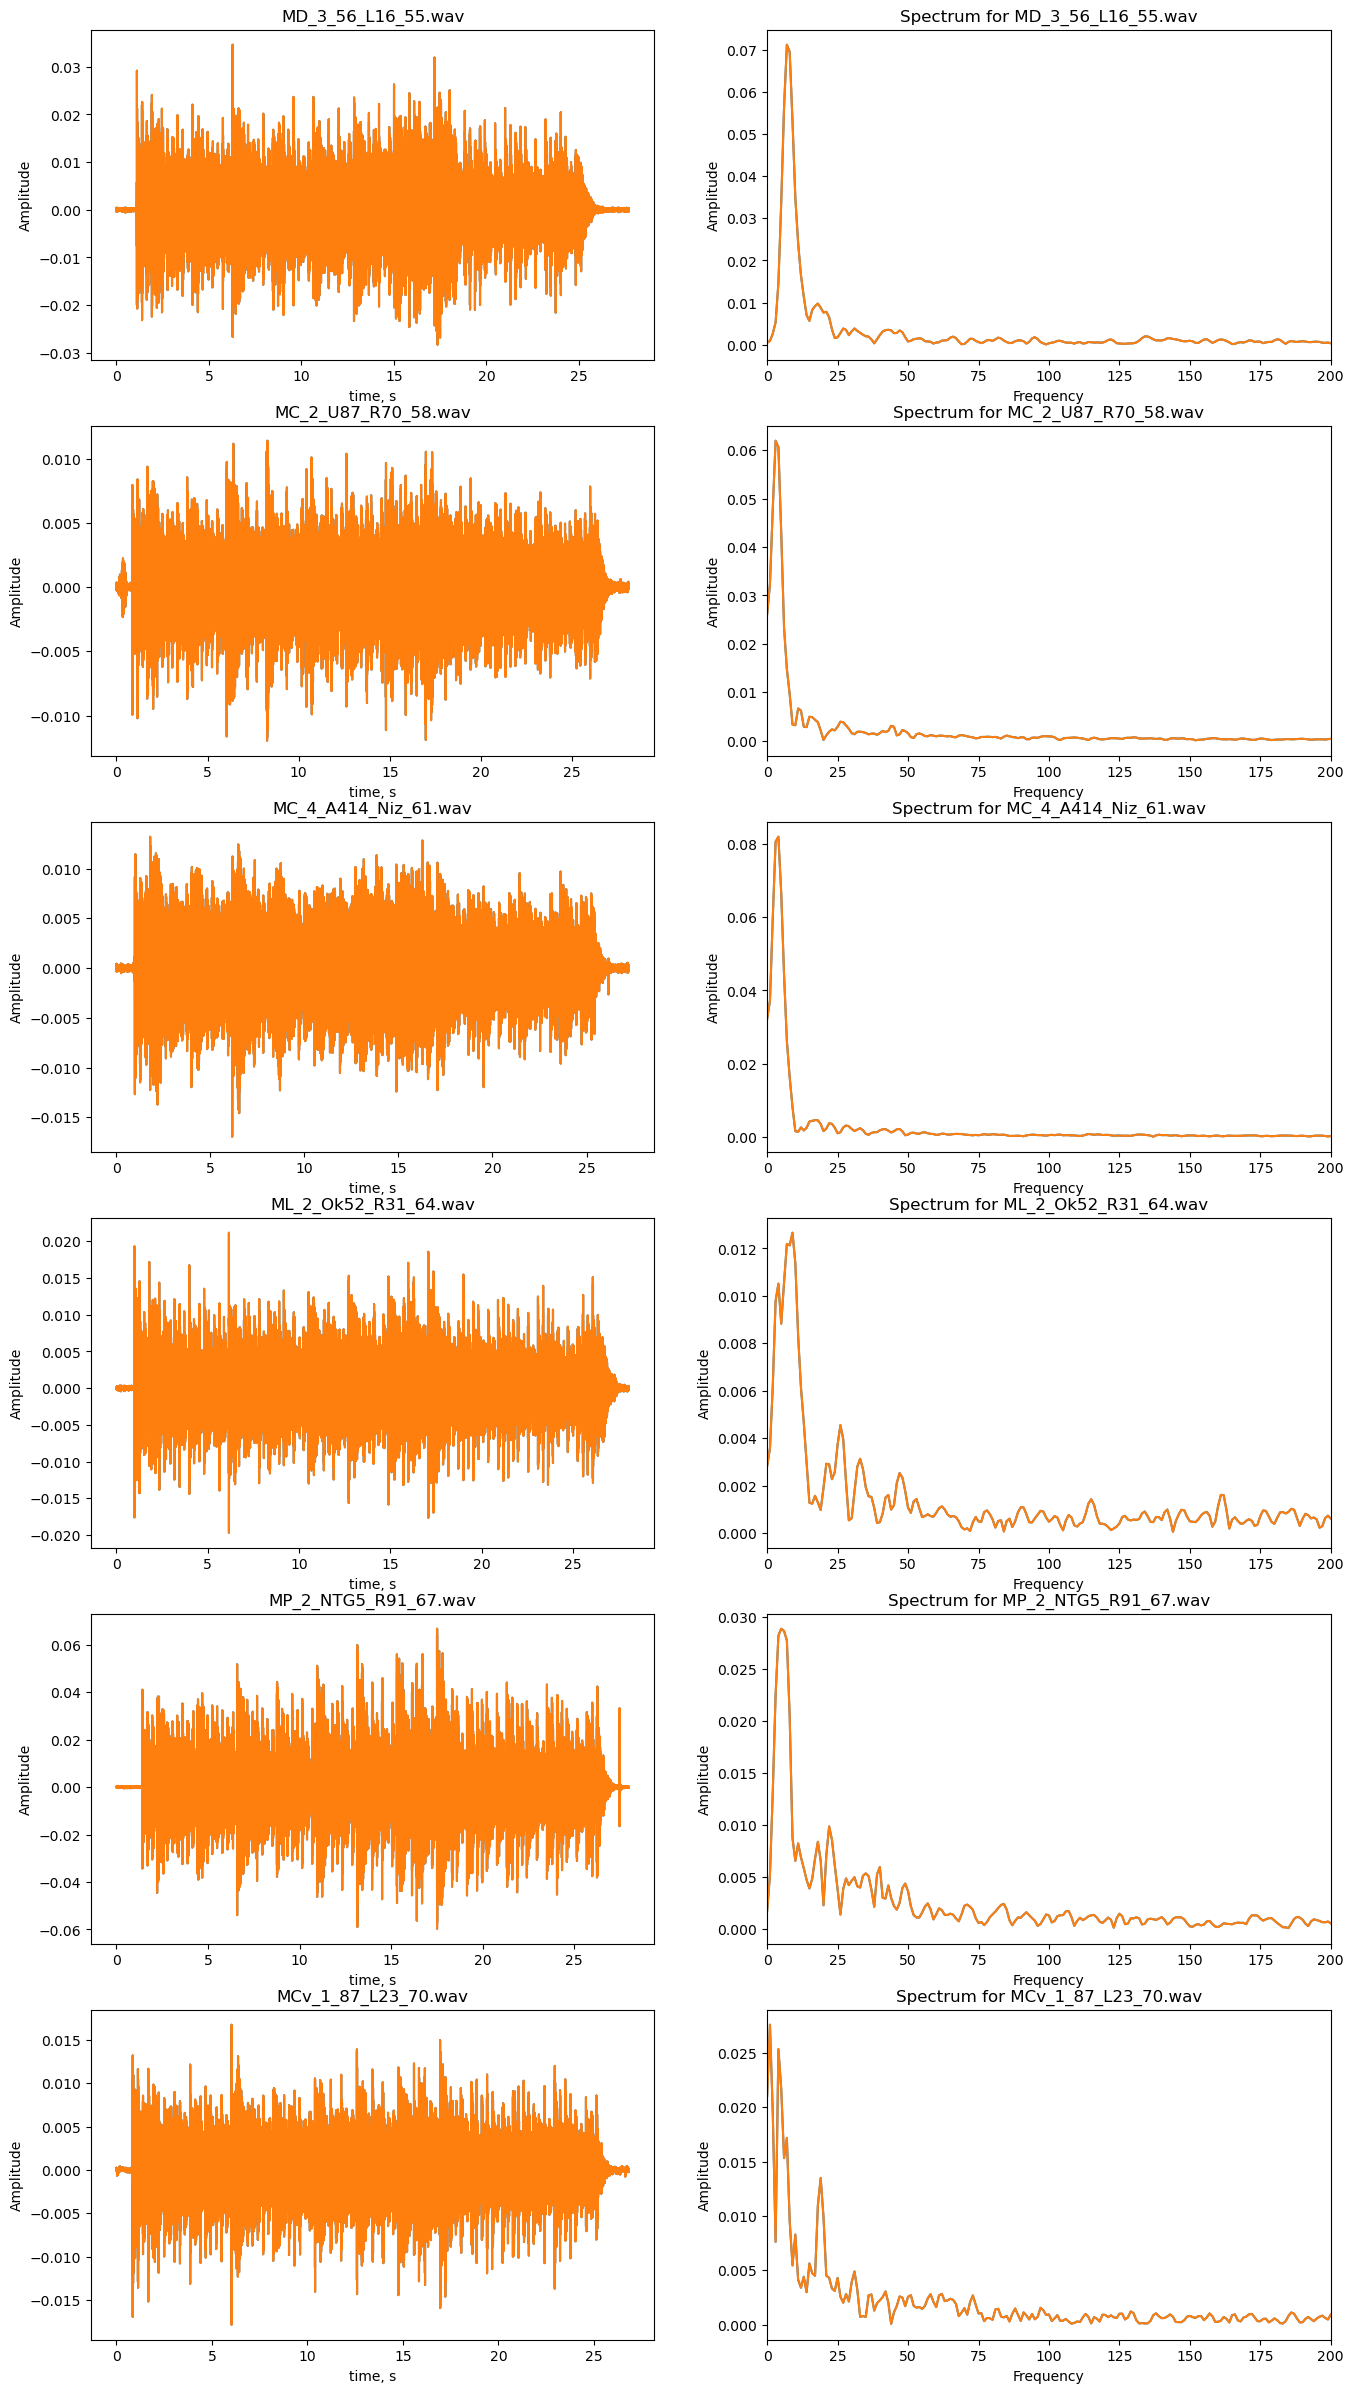

In [ ]:
fig, ax = plt.subplots(6, 2, figsize=(16, 30))
n_fft = 2048 # длина оконного сигнала после заполнения нулями (для преобразования Фурье)
for i in range(0, 6):
    for j in range(2):
        k = 12 # для переключения на третью группу из 6 микрофонов
        time = np.arange(0, len(loaded_kalib[k+i][0])) / loaded_kalib[k+i][1]
        ax[i][0].plot(time, loaded_kalib[k+i][0])
        ax[i][0].set_title(kalib_lst[k+i])
        ax[i][0].set_xlabel('time, s')
        ax[i][0].set_ylabel('Amplitude')
        ax[i][1].plot(np.abs(librosa.stft(loaded_kalib[k+i][0][:n_fft], hop_length = n_fft+1)))
        ax[i][1].set_xlim(0, 200)
        ax[i][1].set_title('Spectrum for ' + kalib_lst[k+i])
        ax[i][1].set_xlabel('Frequency')
        ax[i][1].set_ylabel('Amplitude')

Соберем все статистики по микрофонам:

In [ ]:
# получаем абс пути до файлов и зсчитываем из с помощью метода load библиотеки vibrosa
tmp = [] # список для сохранения информации
main_dir = os.getcwd() # путь до рабочей директории
for file in kalib_lst:
    path = os.path.abspath(os.path.join(main_dir, 'Audio_Files\\' + file)) # путь до файла
    signal, sr = librosa.load(path, sr = 22050)
    # время сигнала (в сек)
    time = len(signal) / sr
    # макс. амплитуда сигнала
    max_abs_a = max(abs(signal))
    # мел-кепстральные коэффициенты
    mfcc = librosa.feature.mfcc(y=signal, sr=sr)
    mfcc_mean = np.mean(mfcc, axis=1) # их средние значения
    mfcc_std = np.std(librosa.feature.mfcc(y=signal, sr=sr), axis=1)
    # спектральный центроид
    cent = librosa.feature.spectral_centroid(y=signal, sr=sr)
    cent_mean = np.mean(cent) # его средние значения
    cent_std = np.std(cent)  # его стандартные отклонения
    # спектральный спад
    rolloff = librosa.feature.spectral_rolloff(y=signal, sr=sr)
    rolloff_mean = np.mean(rolloff)
    rolloff_std = np.std(rolloff)
    # добавляем характеристики в список
    exp = int(file[file.index('.') - 2:file.index('.')]) # номер эксперимента
    mic_name = file[:file.index('.') - 3]
    if exp in [53, 56, 59, 62, 65]:
        distance = 1
    elif exp in [64, 57, 60, 63, 66, 69]:
        distance = 50
    elif exp in [55, 58, 61, 64, 67, 70]:
        distance = 100
    tmp.append([exp, mic_name, time, max_abs_a, mfcc_mean,  mfcc_std, cent_mean, cent_std, rolloff_mean, rolloff_std])

Формируем датафрейм для микрофонов, которые использовались для калибровки.

In [ ]:
kalib_mic_df = pd.DataFrame(tmp)
kalib_mic_df.columns = [
    'exp_№', 'mic_name', 'time', 'max_abs_a', 'mfcc_mean', 'mfcc_std',
    'cent_mean', 'cent_std', 'rolloff_mean', 'rolloff_std'
]
kalib_mic_df

,exp_№,mic_name,time,max_abs_a,mfcc_mean,mfcc_std,cent_mean,cent_std,rolloff_mean,rolloff_std
0,53,MD_3_56_L16,29.562585,0.531408,"[-325.67468, 54.63031, -100.94755, 48.58047, -...","[173.45248, 26.861614, 53.074917, 16.88688, 17...",2801.818591,350.185379,4496.070275,1324.923030
1,56,MC_2_U87_R70,29.070340,0.155634,"[-376.95093, 68.32563, -115.7383, 38.812817, -...","[118.419586, 29.863224, 41.21038, 14.84442, 9....",2437.175059,353.727484,3645.621166,837.704140
2,59,MC_4_A414_Niz,26.246621,0.278593,"[-355.60898, 59.085922, -121.38212, 46.975395,...","[126.86206, 25.838936, 42.73447, 14.254438, 12...",2584.094301,376.725793,3918.148132,643.905248
3,62,ML_2_Ok52_R31,28.947166,0.166500,"[-392.51865, 107.95473, -109.56172, 73.556145,...","[122.25322, 28.65845, 45.33909, 19.672075, 10....",2384.344830,309.771564,3802.976068,1082.938877
4,65,MP_2_NTG5_R91,27.150839,0.298282,"[-350.744, 57.103184, -107.041115, 57.916725, ...","[130.77586, 24.322771, 45.59406, 18.303194, 13...",2647.169911,289.482984,4210.551007,848.472697
5,68,MCv_1_87_L23,28.320998,0.239489,"[-346.51123, 57.75723, -107.8637, 53.109898, -...","[117.64939, 26.160156, 37.248844, 13.471959, 1...",2695.332576,257.366471,4123.211270,778.982157
6,54,MD_3_56_L16,28.321497,0.061040,"[-473.56445, 55.30461, -106.774994, 48.09241, ...","[101.50421, 22.992964, 44.0561, 12.2676735, 11...",2676.745766,286.128186,4268.939869,1118.463226
7,57,MC_2_U87_R70,30.646984,0.020604,"[-544.58026, 79.588, -114.5235, 41.65359, -5.8...","[68.14386, 24.244888, 32.193497, 12.227651, 8....",2409.314973,279.751147,3704.436867,722.663556
8,60,MC_4_A414_Niz,26.746259,0.024198,"[-543.62524, 76.428566, -107.21485, 48.558426,...","[111.88821, 23.666178, 47.122196, 13.259111, 1...",2419.367784,383.570041,3801.825333,482.348679
9,63,ML_2_Ok52_R31,26.092925,0.036781,"[-521.55804, 71.18699, -103.929245, 59.94555, ...","[84.88134, 17.968697, 43.07193, 18.252298, 8.5...",2667.513062,416.020485,4155.841151,1340.351872


Сохраняем датафрейм в JSON формате.

In [ ]:
kalib_mic_df.to_json('kalib_mic_df.json')

Проделаем аналогичные действия для всех данных, полученных в ходе калибровачных тестов:

In [ ]:
exp_num = list(range(53, 71)) #итзвестные номера экспериментов, в которых производилась калибровка
# известные названия микрофоном, для которых производилась калибровка
mic_names = [
    'MD_3_56_L16', 'MC_2_U87_R70', 'MC_4_A414_Niz',
    'ML_2_Ok52_R31', 'MP_2_NTG5_R91', 'MCv_1_87_L23'
]

In [ ]:
sp = []
main_dir = os.getcwd()
for exp in exp_num:
    for name in mic_names:
        path = os.path.abspath(os.path.join(main_dir, 'Audio_Files\\' + '{0}_{1}.wav'.format(name, exp)))
        signal, sr = librosa.load(path, sr = 22050)
        # время сигнала (в сек)
        time = len(signal) / sr
        # макс. амплитуда сигнала
        max_abs_a = max(abs(signal))
        # мел-кепстральные коэффициенты
        mfcc = librosa.feature.mfcc(y=signal, sr=sr)
        mfcc_mean = np.mean(mfcc, axis=1) # их средние значения
        mfcc_std = np.std(librosa.feature.mfcc(y=signal, sr=sr), axis=1)  # их стандартные отклонения
        # спектральный центроид
        cent = librosa.feature.spectral_centroid(y=signal, sr=sr)
        cent_mean = np.mean(cent) # его средние значения
        cent_std = np.std(cent)  # его стандартные отклонения
        # спектральный спад
        rolloff = librosa.feature.spectral_rolloff(y=signal, sr=sr)
        rolloff_mean = np.mean(rolloff)
        rolloff_std = np.std(rolloff)
        # добавляем характеристики в список
        exp = int(file[file.index('.') - 2:file.index('.')]) # номер эксперимента
        mic_name = file[:file.index('.') - 3]
        if exp in [53, 56, 59, 62, 65]:
            distance = 1
        elif exp in [64, 57, 60, 63, 66, 69]:
            distance = 50
        elif exp in [55, 58, 61, 64, 67, 70]:
            distance = 100
        else:
            distance = None # так как для этих случаем не извекстно точное значение расстояния от источника до микрофона
        sp.append([exp, mic_name, time, max_abs_a, mfcc_mean,  mfcc_std, cent_mean, cent_std, rolloff_mean, rolloff_std])
full_df = pd.DataFrame(sp)
full_df.columns =  [
    'exp_№', 'mic_name', 'time', 'max_abs_a', 'mfcc_mean', 'mfcc_std',
    'cent_mean', 'cent_std', 'rolloff_mean', 'rolloff_std'
]
full_df

,exp_№,mic_name,time,max_abs_a,mfcc_mean,mfcc_std,cent_mean,cent_std,rolloff_mean,rolloff_std
0,70,MCv_1_87_L23,29.562585,0.531408,"[-325.67468, 54.63031, -100.94755, 48.58047, -...","[173.45248, 26.861614, 53.074917, 16.88688, 17...",2801.818591,350.185379,4496.070275,1324.923030
1,70,MCv_1_87_L23,26.820181,0.006790,"[-621.35016, 102.1897, -103.77893, 45.826984, ...","[73.49461, 20.131927, 36.287037, 11.864809, 11...",2215.230287,275.573272,3528.250724,521.399186
2,70,MCv_1_87_L23,26.820181,0.013204,"[-574.3021, 99.085205, -110.41067, 52.052837, ...","[83.444626, 23.619434, 38.90366, 12.961913, 11...",2291.756250,339.873025,3589.925841,574.846366
3,70,MCv_1_87_L23,26.820181,0.008283,"[-577.9977, 81.63973, -81.85377, 33.050823, 4....","[54.268333, 14.8595915, 31.325268, 12.537365, ...",2479.756657,343.507622,3926.940960,1157.688998
4,70,MCv_1_87_L23,26.820181,0.013224,"[-547.2565, 95.57634, -104.44198, 44.22932, -9...","[71.99948, 18.287678, 37.8882, 13.055162, 11.5...",2372.669173,230.411265,3899.689164,808.601359
...,...,...,...,...,...,...,...,...,...,...
103,70,MCv_1_87_L23,26.820181,0.006790,"[-621.35016, 102.1897, -103.77893, 45.826984, ...","[73.49461, 20.131927, 36.287037, 11.864809, 11...",2215.230287,275.573272,3528.250724,521.399186
104,70,MCv_1_87_L23,26.820181,0.013204,"[-574.3021, 99.085205, -110.41067, 52.052837, ...","[83.444626, 23.619434, 38.90366, 12.961913, 11...",2291.756250,339.873025,3589.925841,574.846366
105,70,MCv_1_87_L23,26.820181,0.008283,"[-577.9977, 81.63973, -81.85377, 33.050823, 4....","[54.268333, 14.8595915, 31.325268, 12.537365, ...",2479.756657,343.507622,3926.940960,1157.688998
106,70,MCv_1_87_L23,26.820181,0.013224,"[-547.2565, 95.57634, -104.44198, 44.22932, -9...","[71.99948, 18.287678, 37.8882, 13.055162, 11.5...",2372.669173,230.411265,3899.689164,808.601359


Сохраняем его в формате csv.

In [ ]:
full_df.to_csv('full_kalib.csv')